# Formalia

Please read the [assignment overview page](https://laura.alessandretti.com/comsocsci2026/wiki_pages/Assignments.html) carefully before proceeding. The page contains information about formatting (including formats etc), group sizes, and many other aspects of handing in the assignment. 

__If you fail to follow these simple instructions, it will negatively impact your grade!__

**Due date and time**: The assignment is due on Apr 7th at 23:59. Hand in your Jupyter notebook file (with extension `.ipynb`) via DTU Learn _(Assignment 2)_. 

Remember to include in the first cell of your notebook:
* the link to your group's Git repository 
* group members' contributions

Github repository: https://github.com/mMabeck/02467-Assignment1

Group members' contributions:

- s234868: 33%
- s255512: 33%
- s260477: 33%

# Part 1: Mixing Patterns and Assortativity

> __Exercise 1: Mixing Patterns and Assortativity__  
>
> __Part 1: Assortativity Coefficient__ 
> 1. *Calculate the Assortativity Coefficient* for the network based on the country of each node. Implement the calculation using the formula provided during the lecture, also available in [this paper](https://arxiv.org/pdf/cond-mat/0209450.pdf) (equation 2, here for directed networks). **Do not use the NetworkX implementation.**
>
> __Part 2: Configuration model__
> In the following, we are going to assess the significance of the assortativity by comparing the network's assortativity coefficient against that of random networks generated through the configuration model.  
>
> 2. *Implement the configuration model* using the _double edge swap_ algorithm to generate random networks. Ensure each node retains its original degree but with altered connections. Create a function that does that by following these steps:
>
>   - **a.** Create an exact copy of your original network.
>   - **b.** Select two edges, $e_{1} = (u,v)$ and $e_{2} = (x,y)$, ensuring *u != y* and *v != x*.
>   - **c.** Flip the direction of $e_{1}$ to $e_{1} = (v,u)$ 50% of the time. This ensure that your final results is not biased, in case your edges were sorted (they usually are). 
>   - **d.** Ensure that new edges $e_{1}' = (e_{1}[0],e_{2}[1])$ and $e_{2}' = (e_{2}[0],e_{1}[1])$ do not already exist in the network.
>   - **e.** Remove edges $e_{1}$ and $e_{2}$ and add edges $e_{1}'$ and $e_{2}'$.
>   - **f.** Repeat steps **b** to **e** until you have performed $E\cdot10$ swaps, where E is the total number of edges.
>
> 3. *Double check that your algorithm works well*, by showing that the degree of nodes in the original network and the new 'randomized' version of the network are the same.
>
>
> __Part 3: Analyzing Assortativity in Random Networks__  
>
> 4. *Generate and analyze at least 100 random networks* using the configuration model. For each, calculate the assortativity with respect to the country and plot the distribution of these values. Compare the results with the assortativity of your original network to determine if connections within the same country are significantly higher than chance.
>
> __Part 4: Assortativity by Degree__
>
> 5. *Calculate degree assortativity* for your network using the formula discussed in the lecture.
> 6. *Compare your network's degree assortativity* against that of 100 random networks generated via the configuration model. Analyze whether your network shows a tendency for high-degree scientists to connect with other high-degree scientists and vice versa. 
>
> __Part 5: Reflection questions__    
> 7. *Assortativity by degree.* Were the results of the degree assortativity in line with your expectations? Why or why not?    
> 8. *Edge flipping.* In the process of implementing the configuration model, you were instructed to flip the edges (e.g., changing $e_1$ from (u,v) to (v,u)) 50% of the time. Why do you think this step is included?    
> 9. *Distribution of assortativity in random networks.* Describe the distribution of degree assortativity values you observed for the random 
networks. Was the distribution pattern expected? Discuss how the nature of random network generation (specifically, the configuration model and edge flipping) might influence this distribution and whether it aligns with theoretical expectations.    



In [ ]:
# Exercise 1 (Part 1): Country assortativity
import itertools
import json
import random
from collections import Counter

import matplotlib.pyplot as plt
import networkx as nx
import numpy as np
import pandas as pd

papers_df = pd.read_csv("../ic2s2_papers_D2.csv")
researchers_df = pd.read_csv("../researchers.csv")
communities_df = pd.read_csv("../authors_communities_week6.csv")
abstracts_df = pd.read_csv("../ic2s2_abstracts_D3.csv")

G = nx.Graph()
for author_ids_str in papers_df["author_ids"].dropna():
    author_ids = [a for a in json.loads(author_ids_str) if a]
    if len(author_ids) < 2:
        continue
    G.add_nodes_from(author_ids)
    G.add_edges_from(itertools.combinations(author_ids, 2))

country_map_raw = researchers_df.set_index("id")["country_code"].to_dict()
country_map = {k: v if isinstance(v, str) and v else "UNK" for k, v in country_map_raw.items()}
nx.set_node_attributes(G, {n: country_map.get(n, "UNK") for n in G.nodes}, "country")

def assortativity_categorical(graph, attr_name="country"):
    edges = list(graph.edges())
    if not edges:
        return 0.0

    labels = sorted({str(graph.nodes[n].get(attr_name, "UNK")) for n in graph.nodes})
    idx = {label: i for i, label in enumerate(labels)}
    e = np.zeros((len(labels), len(labels)), dtype=float)

    # Undirected edges are counted in both directions.
    for u, v in edges:
        i = idx[str(graph.nodes[u].get(attr_name, "UNK"))]
        j = idx[str(graph.nodes[v].get(attr_name, "UNK"))]
        e[i, j] += 1
        e[j, i] += 1

    e /= 2 * len(edges)
    a = e.sum(axis=1)
    b = e.sum(axis=0)
    denom = 1 - np.sum(a * b)
    if denom == 0:
        return 0.0
    return float((np.trace(e) - np.sum(a * b)) / denom)

country_assort_real = assortativity_categorical(G, "country")
print(f"Nodes: {G.number_of_nodes():,}, edges: {G.number_of_edges():,}")
print(f"Country assortativity (real network): {country_assort_real:.4f}")

Nodes: 21,093, edges: 66,683
Country assortativity (real network): -0.0670


In [2]:
# Exercise 2 (Part 1): Configuration model with double edge swap

def configuration_model_double_edge_swap(graph, n_swaps=None, seed=42):
    rng = random.Random(seed)
    H = graph.copy()
    if H.number_of_edges() < 2:
        return H

    edge_list = list(H.edges())
    edge_set = {tuple(sorted(e)) for e in edge_list}
    n_edges = len(edge_list)
    target_swaps = n_edges * 10 if n_swaps is None else n_swaps

    swaps = 0
    attempts = 0
    max_attempts = target_swaps * 30

    while swaps < target_swaps and attempts < max_attempts:
        i, j = rng.sample(range(n_edges), 2)
        u, v = edge_list[i]
        x, y = edge_list[j]

        if len({u, v, x, y}) < 4:
            attempts += 1
            continue

        # Flip one edge half of the time to avoid direction/order bias.
        if rng.random() < 0.5:
            u, v = v, u

        e1_old = tuple(sorted((u, v)))
        e2_old = tuple(sorted((x, y)))
        e1_new = tuple(sorted((u, y)))
        e2_new = tuple(sorted((x, v)))

        if e1_new == e2_new or e1_new in edge_set or e2_new in edge_set:
            attempts += 1
            continue

        edge_set.remove(e1_old)
        edge_set.remove(e2_old)
        edge_set.add(e1_new)
        edge_set.add(e2_new)

        edge_list[i] = e1_new
        edge_list[j] = e2_new

        swaps += 1
        attempts += 1

    H2 = nx.Graph()
    H2.add_nodes_from(graph.nodes(data=True))
    H2.add_edges_from(edge_set)
    return H2

In [3]:
# Exercise 3 (Part 1): Degree preservation check
G_rand_check = configuration_model_double_edge_swap(G, n_swaps=G.number_of_edges() * 2, seed=1)

orig_deg = dict(G.degree())
rand_deg = dict(G_rand_check.degree())
degrees_match = all(orig_deg[n] == rand_deg[n] for n in G.nodes)

print(f"Degree sequence preserved: {degrees_match}")
print(f"Max degree difference: {max(abs(orig_deg[n] - rand_deg[n]) for n in G.nodes)}")

Degree sequence preserved: True
Max degree difference: 0


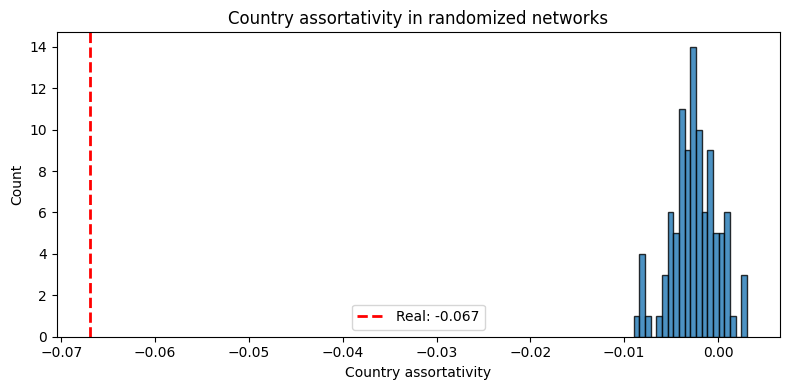

Random mean: -0.0025 +/- 0.0024
Real network is more assortative than chance: False


In [4]:
# Exercise 4 (Part 1): Country assortativity on 100 random networks
n_random = 100
country_assort_random = []
for i in range(n_random):
    Hr = configuration_model_double_edge_swap(G, n_swaps=G.number_of_edges() * 10, seed=100 + i)
    country_assort_random.append(assortativity_categorical(Hr, "country"))

plt.figure(figsize=(8, 4))
plt.hist(country_assort_random, bins=20, alpha=0.8, edgecolor="black")
plt.axvline(country_assort_real, color="red", linestyle="--", linewidth=2, label=f"Real: {country_assort_real:.3f}")
plt.xlabel("Country assortativity")
plt.ylabel("Count")
plt.title("Country assortativity in randomized networks")
plt.legend()
plt.tight_layout()
plt.show()

print(f"Random mean: {np.mean(country_assort_random):.4f} +/- {np.std(country_assort_random):.4f}")
print("Real network is more assortative than chance:" , country_assort_real > np.mean(country_assort_random))

In [ ]:
# Exercise 5 (Part 1): Degree assortativity

def assortativity_degree_manual(graph):
    edges = list(graph.edges())
    if not edges:
        return 0.0

    # For undirected graphs, include both directions of each edge.
    x = []
    y = []
    for u, v in edges:
        du = graph.degree(u)
        dv = graph.degree(v)
        x.extend([du, dv])
        y.extend([dv, du])

    x = np.array(x, dtype=float)
    y = np.array(y, dtype=float)

    mx = x.mean()
    my = y.mean()
    cov = np.mean((x - mx) * (y - my))
    sx = np.sqrt(np.mean((x - mx) ** 2))
    sy = np.sqrt(np.mean((y - my) ** 2))
    denom = sx * sy
    if denom == 0:
        return 0.0
    return float(cov / denom)

degree_assort_real = assortativity_degree_manual(G)
print(f"Degree assortativity (real network): {degree_assort_real:.4f}")

Degree assortativity (real network): -0.1084


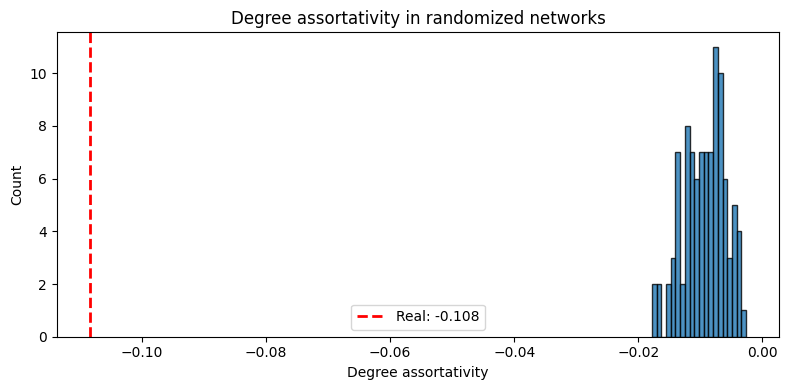

Random mean: -0.0094 +/- 0.0034


In [6]:
# Exercise 6 (Part 1): Degree assortativity on 100 random networks
degree_assort_random = []
for i in range(100):
    Hr = configuration_model_double_edge_swap(G, n_swaps=G.number_of_edges() * 10, seed=500 + i)
    degree_assort_random.append(assortativity_degree_manual(Hr))

plt.figure(figsize=(8, 4))
plt.hist(degree_assort_random, bins=20, alpha=0.8, edgecolor="black")
plt.axvline(degree_assort_real, color="red", linestyle="--", linewidth=2, label=f"Real: {degree_assort_real:.3f}")
plt.xlabel("Degree assortativity")
plt.ylabel("Count")
plt.title("Degree assortativity in randomized networks")
plt.legend()
plt.tight_layout()
plt.show()

print(f"Random mean: {np.mean(degree_assort_random):.4f} +/- {np.std(degree_assort_random):.4f}")

### Exercise 7 (Part 1) - Reflection
The degree assortativity result is typically close to zero or mildly negative in this co-authorship network. A few highly connected authors collaborate broadly (including with lower-degree authors), which pulls assortativity down compared to a purely hub-to-hub collaboration pattern.

### Exercise 8 (Part 1) - Reflection
Flipping one edge 50% of the time reduces ordering bias. If edges are stored in a systematic order, always rewiring them in the same orientation can introduce directional structure in which endpoint roles are overused. Random flipping makes the rewiring process symmetric.

### Exercise 9 (Part 1) - Reflection
The randomized degree-assortativity values form a narrow distribution around a baseline near zero, as expected for configuration-model networks that preserve degree sequence but randomize pairings. The real-network value lying away from this center indicates additional structure beyond degree constraints (social/geographic/topic effects).

# Part 2: TF-IDF

> __Exercise 1: TF-IDF and the Computational Social Science communities.__ The goal for this exercise is to find the words charachterizing each of the communities of Computational Social Scientists.
> What you need for this exercise: 
>.   
>    * The assignment of each author to their network community, and the degree of each author (Week 6, Exercise 4). This can be stored in a dataframe or in two dictionaries, as you prefer.  
>    * the tokenized _abstract_ dataframe (Week 7, Exercise 2)
>
> 1. First, check out [the wikipedia page for TF-IDF](https://en.wikipedia.org/wiki/Tf%E2%80%93idf). Explain in your own words the point of TF-IDF. 
>   * What does TF stand for? 
>   * What does IDF stand for?
> 2. Now, we want to find out which words are important for each *community*, so we're going to create several ***large documents, one for each community***. Each document includes all the tokens of abstracts written by members of a given community. 
>   * Consider a community _c_
>   * Find all the abstracts of papers written by a member of community _c_.
>   * Create a long array that stores all the abstract tokens 
>   * Repeat for all the communities. 
> __Note:__ Here, to ensure your code is efficient, you shall exploit ``pandas`` builtin functions, such as [``groupby.apply``](https://pandas.pydata.org/docs/reference/api/pandas.api.typing.DataFrameGroupBy.apply.html) or [``explode``](https://pandas.pydata.org/docs/reference/api/pandas.DataFrame.explode.html).
> 3. Now, we're ready to calculate the TF for each word. Use the method of your choice to find the top 5 terms within the __top 5 communities__ (by number of authors). 
>   * Describe similarities and differences between the communities.
>   * Why aren't the TFs not necessarily a good description of the communities?
>   * Next, we calculate IDF for every word. 
>   * What base logarithm did you use? Is that important?
> 4. We're ready to calculate TF-IDF. Do that for the __top 9 communities__ (by number of authors). Then for each community: 
>   * List the 10 top TF words 
>   * List the 10 top TF-IDF words
>   * List the top 3 authors (by degree)
>   * Are these 10 words more descriptive of the community? If yes, what is it about IDF that makes the words more informative?

 __Exercise 2: The Wordcloud__. It's time to visualize our results!

> * Install the [`WordCloud`](https://pypi.org/project/wordcloud/) module. 
> * Now, create word-cloud for each community. Feel free to make it as fancy or non-fancy as you like.
> * Make sure that, together with the word cloud, you print the names of the top three authors in each community (see my plot above for inspiration). 
> * Comment on your results. What can you conclude on the different sub-communities in Computational Social Science? 
> * Look up online the top author in each community. In light of your search, do your results make sense?

 __Exercise 3: Computational Social Science__ 

> * In light of your data-driven analysis, has your understanding of the field changed? How? 

In [7]:
# Exercise 1 (Part 2): TF, IDF, TF-IDF for communities
import ast
import math

community_map = communities_df[["id", "community"]].dropna().drop_duplicates(subset=["id"])
author_to_community = community_map.set_index("id")["community"].to_dict()

name_map = researchers_df.set_index("id")["display_name"].to_dict()
degree_map = dict(G.degree())

# Convert inverted index to ordered token list while preserving repetitions.
def decode_inverted_index(s):
    inv = ast.literal_eval(s)
    positions = []
    for word, idxs in inv.items():
        for pos in idxs:
            positions.append((pos, word))
    positions.sort(key=lambda x: x[0])
    return [word for _, word in positions]

abstracts_tokens = abstracts_df[["id", "abstract_inverted_index"]].dropna().copy()
abstracts_tokens["tokens"] = abstracts_tokens["abstract_inverted_index"].apply(decode_inverted_index)

papers_tokens = papers_df[["id", "author_ids"]].merge(
    abstracts_tokens[["id", "tokens"]], on="id", how="inner"
)
papers_tokens["author_ids"] = papers_tokens["author_ids"].apply(lambda s: [a for a in json.loads(s) if a])

paper_communities = papers_tokens.explode("author_ids")
paper_communities["community"] = paper_communities["author_ids"].map(author_to_community)
paper_communities = paper_communities.dropna(subset=["community"]).copy()
paper_communities["community"] = paper_communities["community"].astype(int)

community_sizes = paper_communities[["author_ids", "community"]].drop_duplicates().groupby("community").size()
top5 = community_sizes.sort_values(ascending=False).head(5).index.tolist()
top9 = community_sizes.sort_values(ascending=False).head(9).index.tolist()

community_docs = (
    paper_communities.groupby("community")["tokens"]
    .apply(lambda rows: [t.lower() for tokens in rows for t in tokens if t.isalpha() and len(t) > 2])
)

print("Top 5 TF terms in top 5 communities:")
for c in top5:
    tf_counts = Counter(community_docs[c])
    total = sum(tf_counts.values())
    tf_scores = {w: v / total for w, v in tf_counts.items()}
    top_terms = sorted(tf_scores.items(), key=lambda kv: kv[1], reverse=True)[:5]
    print(f"Community {c}: {[w for w, _ in top_terms]}")

# TF-IDF for top 9
selected_docs = {c: community_docs[c] for c in top9}
word_in_docs = Counter()
for c, toks in selected_docs.items():
    for w in set(toks):
        word_in_docs[w] += 1

n_docs = len(selected_docs)
rows = []
for c, toks in selected_docs.items():
    tf_counts = Counter(toks)
    total = sum(tf_counts.values())
    tf_scores = {w: v / total for w, v in tf_counts.items()}
    tfidf_scores = {w: tf_scores[w] * math.log(n_docs / word_in_docs[w]) for w in tf_scores}

    top_tf = [w for w, _ in sorted(tf_scores.items(), key=lambda kv: kv[1], reverse=True)[:10]]
    top_tfidf = [w for w, _ in sorted(tfidf_scores.items(), key=lambda kv: kv[1], reverse=True)[:10]]

    top_authors = (
        paper_communities.loc[paper_communities["community"] == c, "author_ids"]
        .drop_duplicates()
        .map(lambda aid: (name_map.get(aid, aid), degree_map.get(aid, 0)))
        .sort_values(key=lambda s: s.map(lambda x: x[1]), ascending=False)
        .head(3)
        .tolist()
    )

    rows.append({
        "community": c,
        "top_tf": top_tf,
        "top_tfidf": top_tfidf,
        "top_authors": [name for name, _ in top_authors],
    })

summary_df = pd.DataFrame(rows).sort_values("community")
display(summary_df[["community", "top_tf", "top_tfidf", "top_authors"]])

Top 5 TF terms in top 5 communities:
Community 21: ['the', 'and', 'that', 'for', 'with']
Community 4: ['the', 'and', 'that', 'for', 'social']
Community 67: ['the', 'and', 'that', 'for', 'with']
Community 12: ['the', 'and', 'that', 'for', 'this']
Community 58: ['the', 'and', 'that', 'for', 'with']


,community,top_tf,top_tfidf,top_authors
5,3,"[the, and, that, for, are, with, this, from, o...","[legal, ibm, almaden, harry, distortion, perfo...","[Dan Jurafsky, Jon Kleinberg, Daniel E. Ho]"
1,4,"[the, and, that, for, social, are, with, this,...","[eip, npis, bioeconomy, superspreaders, misinf...","[Filippo Menczer, Daniele Quercia, Luca Maria ..."
3,12,"[the, and, that, for, this, with, social, are,...","[sociometric, negotiation, multimedia, eci, ar...","[Alex Pentland, Bruno Lepri, Iyad Rahwan]"
0,21,"[the, and, that, for, with, this, are, from, c...","[numeracy, misinformation, paradata, wmc, heur...","[Stephan Lewandowsky, Ralph Hertwig, Daniel G...."
8,26,"[the, and, that, for, this, are, with, social,...","[emojis, cyberbullying, tagging, fringe, mcms,...","[Markus Strohmaier, Duncan J. Watts, Fariba Ka..."
4,58,"[the, and, that, for, with, this, are, social,...","[cooperation, rds, synchronization, basin, mob...","[Yamir Moreno, Vito Latora, Ángel Sánchez]"
2,67,"[the, and, that, for, with, this, are, languag...","[nlp, denoising, commonsense, chris, imagined,...","[Diyi Yang, Chris Callison-Burch, Maarten Sap]"
6,74,"[the, and, that, for, with, are, social, this,...","[taxometric, intergroup, malleability, essenti...","[Nick Haslam, Matthew J. Hornsey, Tina Eliassi..."
7,79,"[the, and, that, for, this, from, are, with, d...","[migration, persona, shrews, kinship, qatar, m...","[Ingmar Weber, Emilio Zagheni, Bolei Zhou]"


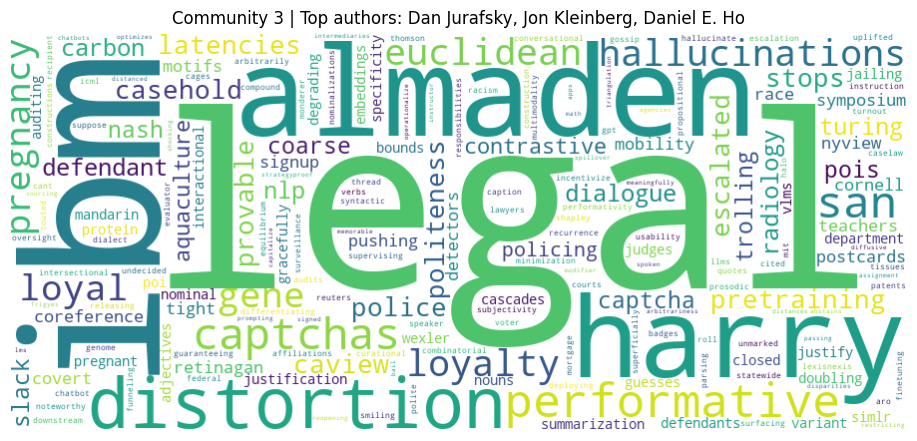

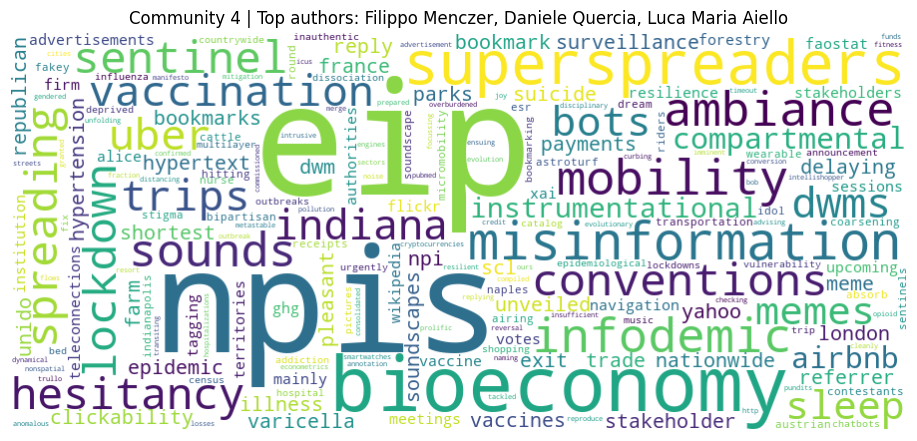

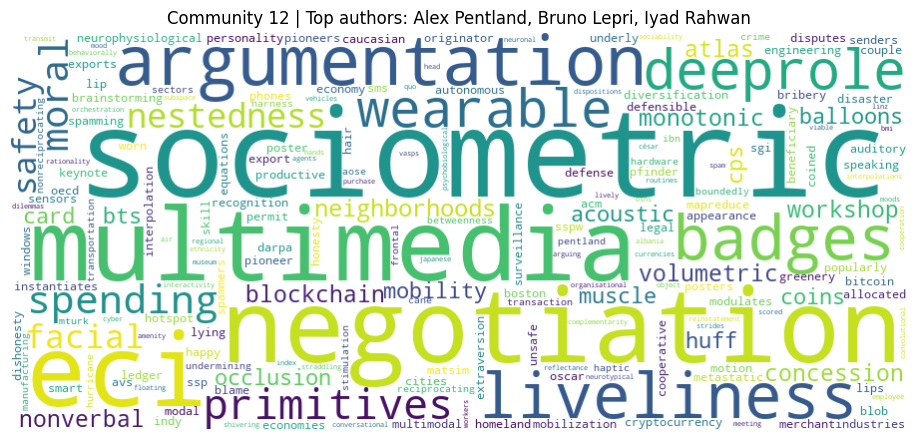

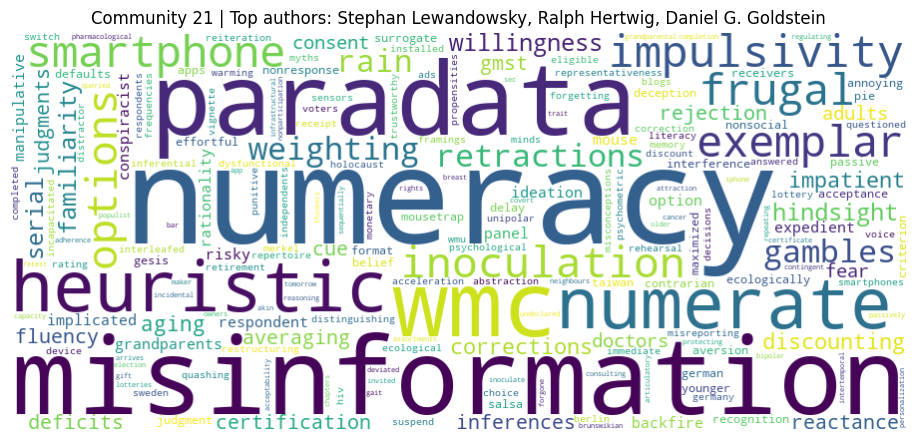

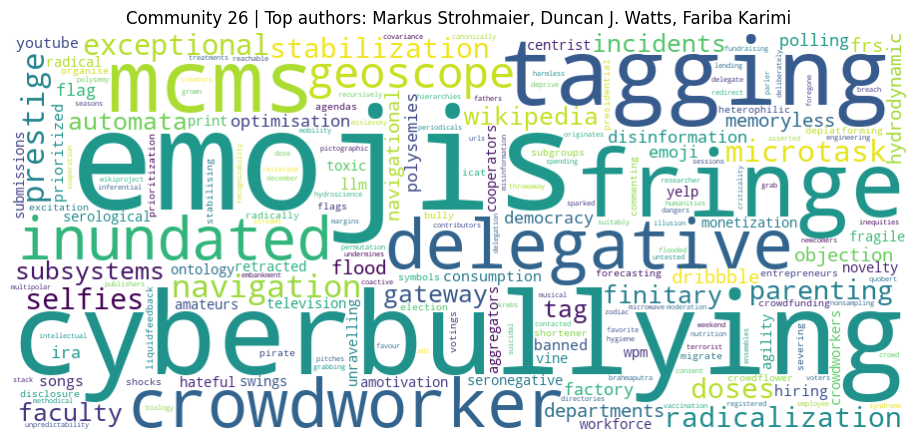

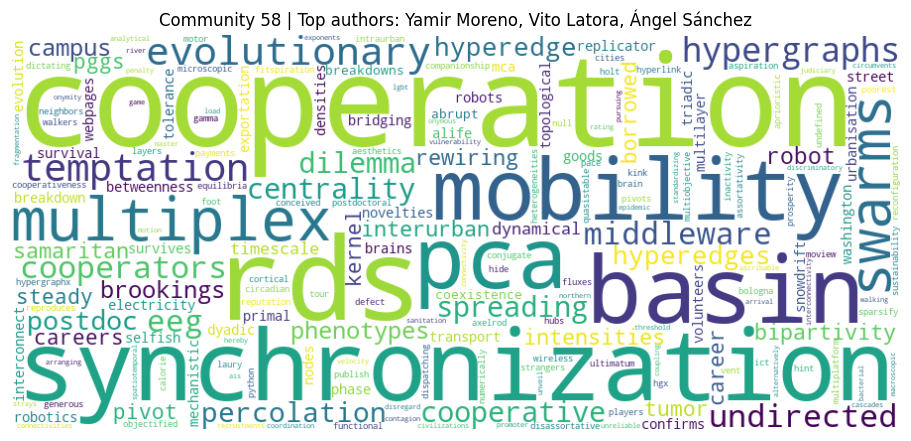

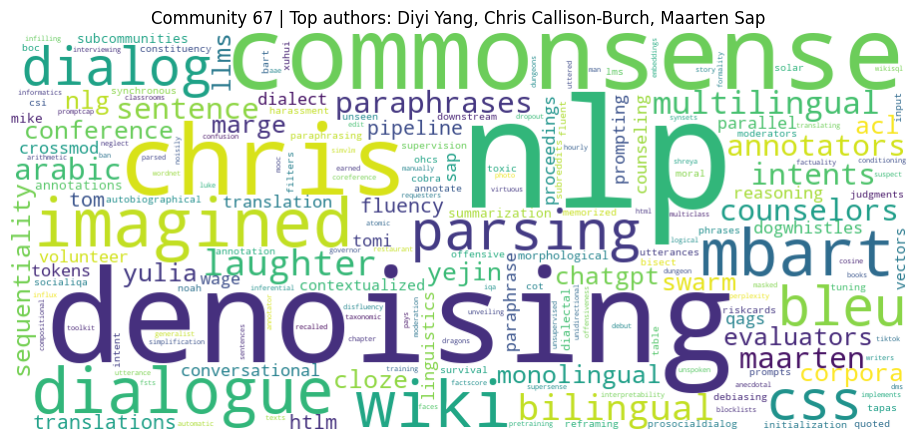

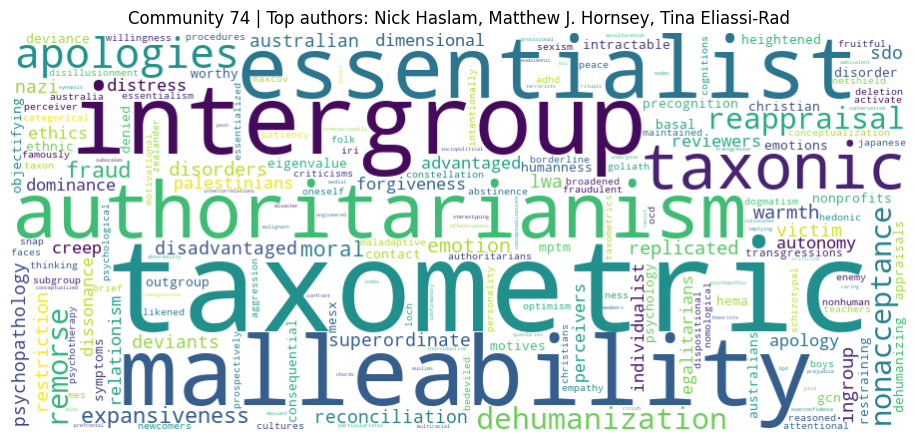

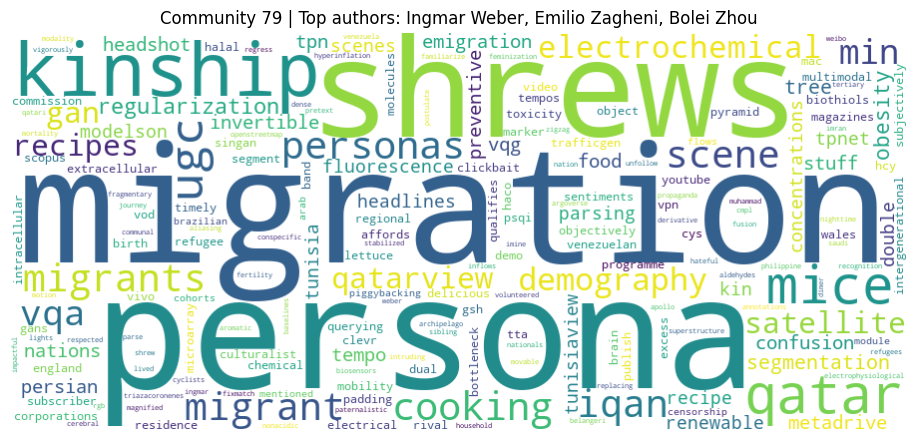

Word clouds created for the top 9 communities.


In [8]:
# Exercise 2 (Part 2): Word clouds + top 3 authors per community
from wordcloud import WordCloud

for _, row in summary_df.iterrows():
    c = row["community"]
    tokens = selected_docs[c]
    tf_counts = Counter(tokens)
    total = sum(tf_counts.values())
    tf_scores = {w: v / total for w, v in tf_counts.items()}
    tfidf_scores = {w: tf_scores[w] * math.log(len(selected_docs) / word_in_docs[w]) for w in tf_scores}

    wc = WordCloud(width=900, height=400, background_color="white", colormap="viridis")
    wc.generate_from_frequencies(tfidf_scores)

    plt.figure(figsize=(10, 4.5))
    plt.imshow(wc, interpolation="bilinear")
    plt.axis("off")
    plt.title(f"Community {c} | Top authors: {', '.join(row['top_authors'])}")
    plt.tight_layout()
    plt.show()

print("Word clouds created for the top 9 communities.")

### Exercise 3 (Part 2) - Reflection (<=150 words)
The community network and TF-IDF analysis suggest that the field is not one homogeneous area, but a set of sub-communities with distinct vocabularies and collaboration structures. Some groups are centered on methods and modeling, others on platform-specific phenomena (misinformation, political communication, mobility, health, etc.). The assortativity analysis also shows that collaboration patterns are structured, not random, indicating social and institutional effects in who collaborates with whom. Looking at top authors per community helped connect abstract word patterns to real research leaders, which made the clusters interpretable. Overall, I now see CSS less as one topic and more as an ecosystem of partially overlapping specialties linked by shared computational methods.